In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jax

loading latest checkpoint from /scratch/ab13780/riemaNN/innt/riemann/checkpoints_rel/F_net_010500.msgpack


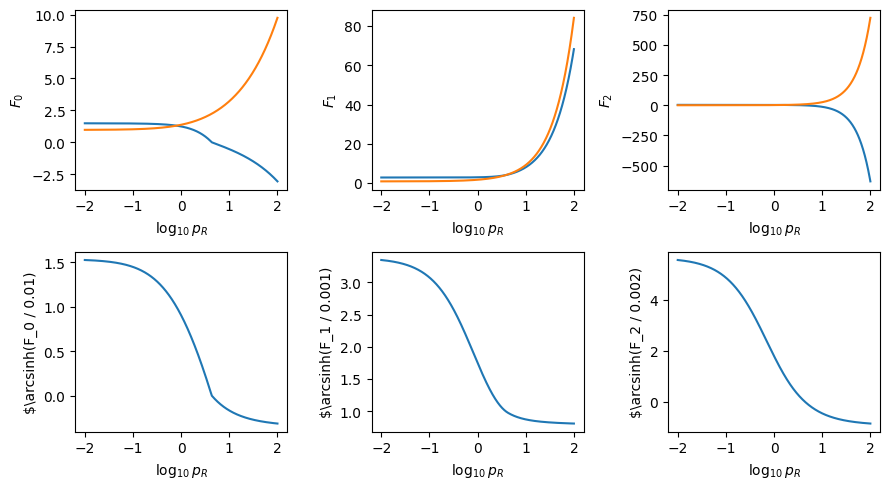

In [7]:
from train_mat import F_true
from physics import flux_from_primitive_state, GAMMA
from checkpoint import load_latest
from train_mat import _build_model, F_pred_nomat, flux_scale
from pathlib import Path

FLUX_SCALE_ARCSINH = jnp.array([1e-2, 1e-3, 2e-3])

ckpt_dir = Path.cwd() / "checkpoints_rel"
F_net, _ = load_latest(ckpt_dir, _build_model)

Npix = 1000

log10rhoL_0, uL_0, log10pL_0 = 0.1, 1.2, 0.
log10rhoR_0, uR_0, log10pR_0 = 0., 0., 0.
t_0 = 0.5

# vary log10rhoR
log10pR = jnp.linspace(-2, 2, 1000)

# all others fixed
t = t_0 * jnp.ones_like(log10pR)
log10rhoL = log10rhoL_0 * jnp.ones_like(log10pR)
uL = uL_0 * jnp.ones_like(log10pR)
log10pL = log10pL_0 * jnp.ones_like(log10pR)
log10rhoR = log10rhoR_0 * jnp.ones_like(log10pR)
uR = uR_0 * jnp.ones_like(log10pR)
# log10pR = log10pR_0 * jnp.ones_like(log10pR)

x = jnp.vstack([t, log10rhoL, uL, log10pL, log10rhoR, uR, log10pR]).T

flux_L = jax.vmap(flux_from_primitive_state)(10.**log10rhoL, uL, 10.**log10pL)
flux_R = jax.vmap(flux_from_primitive_state)(10.**log10rhoR, uR, 10.**log10pR)
flux_LR = 0.5 * (flux_L + flux_R)

rho_ref = jnp.sqrt(10.**log10rhoL * 10.**log10rhoR)
a_L = jnp.sqrt(GAMMA * 10.**log10pL / 10.**log10rhoL)
a_R = jnp.sqrt(GAMMA * 10.**log10pR / 10.**log10rhoR)
a_ref = jnp.maximum(a_L + jnp.abs(uL), a_R + jnp.abs(uR))
flux_ref = jnp.vstack([rho_ref*a_ref, rho_ref*a_ref**2, rho_ref*a_ref**3]).T

# print(x[:10])

flux_true = jax.vmap(F_true)(x)
flux_pred = jax.vmap(lambda r: F_pred_nomat(F_net, r))(x)
F_scale = flux_scale(x)

fig, axs = plt.subplots(2, 3, figsize=(9, 5))

FLUX_SCALE = jnp.array([1e-2, 1e-3, 2e-3])

for i,ax in enumerate(axs[0]):
    ax.plot(log10pR, flux_true[:, i])
    ax.plot(log10pR, F_scale[:, i])
    # ax.plot(log10pR, flux_pred[:, i])
    # ax.plot(log10pR, flux_true[:, i])
    # ax.plot(log10pR, flux_ref[:, i])
    ax.set_xlabel(r'$\log_{10} p_R$')
    ax.set_ylabel(r'$F_{}$'.format(i))

for i,ax in enumerate(axs[1]):
    # ax.plot(log10pR, jnp.arcsinh(flux_true[:, i] / FLUX_SCALE_ARCSINH[i]))
    # ax.plot(log10pR, jnp.arcsinh(flux_pred[:, i] / FLUX_SCALE_ARCSINH[i]))
    ax.plot(log10pR, flux_true[:, i] / F_scale[:, i])
    ax.set_xlabel(r'$\log_{10} p_R$')
    ax.set_ylabel(r'$\arcsinh(F_{} / {})'.format(i, FLUX_SCALE[i]))

fig.tight_layout()
plt.show()


In [5]:
from train_mat import FULL_BOUNDS, draw_rect

import jax.random as jr
key = jr.PRNGKey(0)

x = draw_rect(key, 100_000, FULL_BOUNDS)

flux_true = jax.vmap(F_true)(x)

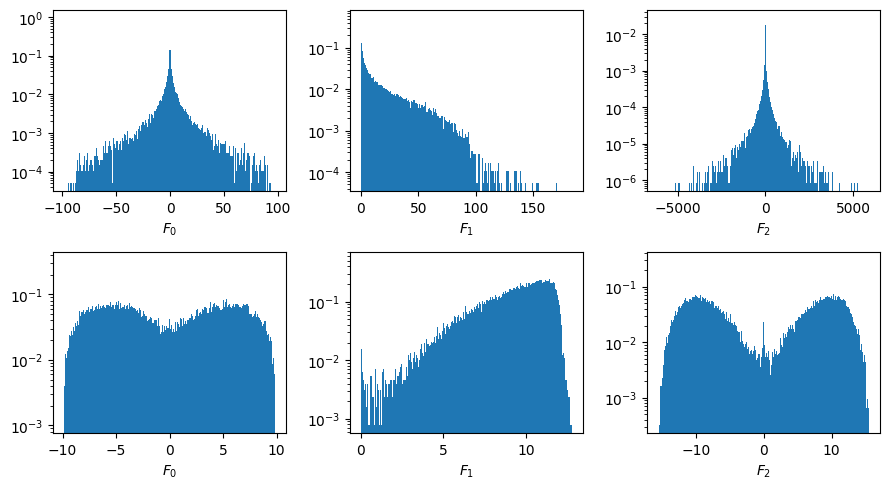

In [13]:
fig, axs = plt.subplots(2, 3, figsize=(9, 5))

FLUX_SCALE = jnp.array([1e-2, 1e-3, 2e-3])

for i,ax in enumerate(axs[0]):
    ax.hist(flux_true[:, i], bins=1000, density=True)
    ax.set_xlabel(r'$F_{}$'.format(i))
    ax.set_yscale('log')

for i,ax in enumerate(axs[1]):
    ax.hist(jnp.arcsinh(flux_true[:, i] / FLUX_SCALE[i]), bins=1000, density=True)
    ax.set_xlabel(r'$F_{}$'.format(i))
    ax.set_yscale('log')

fig.tight_layout()
plt.show()